# 06 — Segmentación con SAM

In [2]:
import supervision as sv
from ultralytics import YOLO, SAM
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path

Path("../../assets/curso/images").mkdir(parents=True, exist_ok=True)

urllib.request.urlretrieve(
    "https://ultralytics.com/images/bus.jpg",
    "../../assets/curso/images/bus.jpg"
)

urllib.request.urlretrieve(
    "https://ultralytics.com/images/zidane.jpg",
    "../../assets/curso/images/zidane.jpg"
)

image = cv2.imread("../../assets/curso/images/bus.jpg")

print(f"Imagen cargada: {image.shape}")

Imagen cargada: (1080, 810, 3)



0: 640x480 4 persons, 1 bus, 1 stop sign, 449.1ms
Speed: 68.8ms preprocess, 449.1ms inference, 17.4ms postprocess per image at shape (1, 3, 640, 480)
YOLO detectó 6 objetos


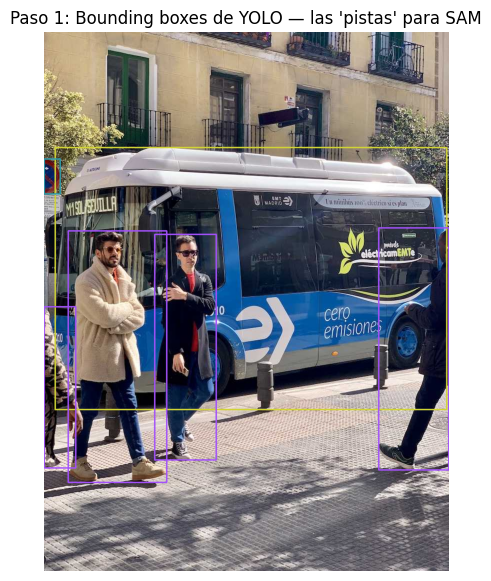

In [3]:
yolo_model = YOLO("../../assets/curso/models/yolov8n.pt")

yolo_results = yolo_model(image)[0]
yolo_detections = sv.Detections.from_ultralytics(yolo_results)

print(f"YOLO detectó {len(yolo_detections)} objetos")

# Visualizar bounding boxes antes de segmentar
box_annotator = sv.BoxAnnotator()

scene_yolo = box_annotator.annotate(
    scene=image.copy(),
    detections=yolo_detections
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(scene_yolo, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Paso 1: Bounding boxes de YOLO — las 'pistas' para SAM")
plt.show()

In [4]:
sam_model = SAM("../../assets/curso/models/sam3.pt")

# SAM espera una lista de Python
bboxes = yolo_detections.xyxy.tolist()

sam_results = sam_model(
    image,
    bboxes=bboxes
)[0]

sam_detections = sv.Detections.from_ultralytics(sam_results)
e
print(f"Detecciones SAM: {len(sam_detections)}")
print(f"¿Tiene máscaras? {sam_detections.mask is not None}")

if sam_detections.mask is not None:
    print(f"Shape de las máscaras: {sam_detections.mask.shape}")
    # (N_objetos, alto_imagen, ancho_imagen)


WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
0: 1036x1036 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 215043.7ms
Speed: 519.4ms preprocess, 215043.7ms inference, 122.2ms postprocess per image at shape (1, 3, 1036, 1036)
Detecciones SAM: 6
¿Tiene máscaras? True
Shape de las máscaras: (6, 1080, 810)
